In [1]:
import pandas as pd
data = pd.read_csv("sensor_data_200.txt",delimiter=" ",
                   header=None,names = ("date","time","ir","lidar"))
data

,date,time,ir,lidar
0,20180122,95819,305,214
1,20180122,95822,299,211
2,20180122,95826,292,199
3,20180122,95829,321,208
4,20180122,95832,298,212
...,...,...,...,...
58983,20180124,120023,313,208
58984,20180124,120026,297,200
58985,20180124,120030,323,204
58986,20180124,120033,326,207


## メモ
pandasのような便利な関数をまとめたものをモジュールという。  
importで読み込み、asで関数の頭につける接頭語を指定。  
接頭語.関数で使用。  
read_csvを使って変数dataにsensor_data_200.txtのデータを読み込む。  
delimiter=" "で区切り文字を指定している。今回は半角スペース。  
header=Noneで今回の元データにヘッダの行がないことを指定。  
names=("","")で各列の名前指定。  

In [2]:
print(data["lidar"][0:5])

0    214
1    211
2    199
3    208
4    212
Name: lidar, dtype: int64


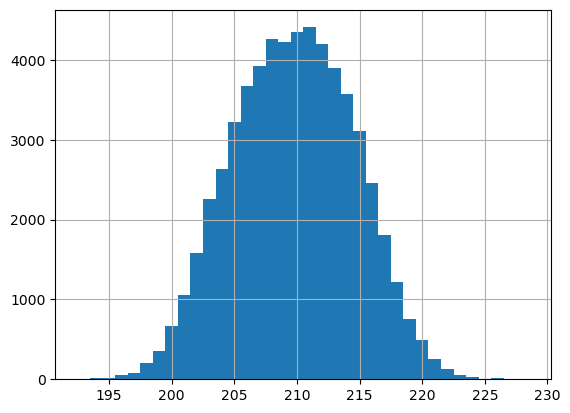

In [3]:
import matplotlib.pyplot as plt
data["lidar"].hist(bins = max(data["lidar"]) - min(data["lidar"]),align='left')
plt.show()

## メモ
Matplotlibというモジュールの下にあるpyplotというモジュールを指定。  
histはヒストグラムを作るための関数。  
引数binsは横軸の各区間のこと。今回は幅を１にするために最大最小の差を使った。  
align="left"は各区間の中央値がLidarの値になるようにするための補正を行う引数。  
今回の場合区間200以上~201未満の中央値が200.5のところを200に変更

In [4]:
mean1 = sum(data["lidar"].values)/len(data["lidar"].values)
mean2 = data["lidar"].mean()
print(mean1,"   ",mean2)

209.73713297619855     209.73713297619855


## メモ
sumはデータの値の合計を求める。  
lenはデータの長さを求める（要素数）Lenge。  
.valuesはなくても計算可能。  
.mean()はpandasにある平均値を計算するメソッド。  

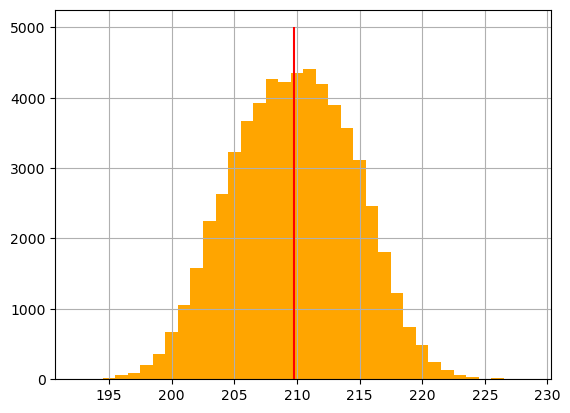

In [5]:
data["lidar"].hist(bins = max(data["lidar"]) - min(data["lidar"]),color="orange",align='left')
plt.vlines(mean1,ymin=0,ymax=5000,color="red")
plt.show()

## メモ  
color="色"でヒストグラムの色指定  
.vlines(値,ymin=下限,ymax=上限,color="色")でグラフ上の下限から上限まで値の位置に**縦線**を引く。  

In [6]:
#定義から計算
zs = data["lidar"].values
mean = sum(zs)/len(zs)
diff_square = [(z-mean)**2 for z in zs]

sampling_var = sum(diff_square)/len(zs)       #標本分散
unbiased_var = sum(diff_square)/(len(zs)-1)   #不偏分散

#Pandasバージョン
pandas_sampling_var = data["lidar"].var(ddof=0)        #標本分散
pandas_unbiased_var = data["lidar"].var()              #不偏分散　Pandasのデフォルトはこっち

#Numpyバージョン
import numpy as np

numpy_sampling_var = np.var(data["lidar"])            #標本分散  Numpyのデフォルトはこっち
numpy_unbiased_var = np.var(data["lidar"],ddof=1)     #不偏分散

print(f"""
定義
標本分散 = {sampling_var}
不偏分散 = {unbiased_var}

Pandasを利用
標本分散 = {pandas_sampling_var}
不偏分散 = {pandas_unbiased_var}

Numpyを利用
標本分散 = {numpy_sampling_var}
不偏分散 = {numpy_unbiased_var}
""")


定義
標本分散 = 23.407709770274106
不偏分散 = 23.40810659855441

Pandasを利用
標本分散 = 23.407709770274106
不偏分散 = 23.40810659855441

Numpyを利用
標本分散 = 23.407709770274106
不偏分散 = 23.40810659855441



## メモ
([z-mean]**2 for z in zs)はzsから１要素ずつ取り出して新しいリスト[z-mean]**2を作るPythonのリスト内包表記  
Pandasではデフォルトで不偏分散を行う。 .var()で分散を求める。 ddof=0をつけることで標本分散も求められる。   
Numpyではデフォルトで標本分散を行う。　np.var(data[""])で求める。　ddof=1をつけると不偏分散も求められる。  
ddofはN-xのxを決めるものだと思われる。  
print(f"""  
""")で中の改行、空白をそのまま反映して出力できる。{}内は変数

In [7]:
import math

#定義から計算
stddev1 = math.sqrt(sampling_var) 
stddev2 = math.sqrt(unbiased_var)

#Pandasバージョン
pandas_stddev = data["lidar"].std()

print(f"""
定義
標本分散からの標準偏差：{stddev1}
不偏分散からの標準偏差：{stddev2}

Pandas利用（不偏分散から求められる）
標準偏差：{pandas_stddev}
""")


定義
標本分散からの標準偏差：4.838151482774605
不偏分散からの標準偏差：4.83819249292072

Pandas利用（不偏分散から求められる）
標準偏差：4.83819249292072



## メモ
mathモジュールの平方根を求めるメソッドsqrt  
pandasモジュールの標準偏差を求めるメソッドstd(不偏分散から求める）

In [8]:
freqs = pd.DataFrame(data["lidar"].value_counts())
#pd.DataFrameでデータフレームに変換　　value_counts()で各センサ値の数を数える。
freqs.transpose()  #横向きに出力

lidar,211,210,208,209,212,207,213,206,214,205,...,197,196,223,224,226,195,194,193,227,229
count,4409,4355,4261,4228,4201,3920,3897,3674,3572,3225,...,84,59,55,32,15,13,10,4,3,1


In [9]:
freqs["probs"] = freqs["count"]/sum(freqs["count"])
#確率の列 probs の追加　
freqs.transpose()

lidar,211,210,208,209,212,207,213,206,214,205,...,197,196,223,224,226,195,194,193,227,229
count,4409.000000,4355.000000,4261.000000,4228.000000,4201.000000,3920.000000,3897.000000,3674.000000,3572.000000,3225.000000,...,84.000000,59.000,55.000000,32.000000,15.000000,13.00000,10.00000,4.000000,3.000000,1.000000
probs,0.074744,0.073829,0.072235,0.071676,0.071218,0.066454,0.066064,0.062284,0.060555,0.054672,...,0.001424,0.001,0.000932,0.000542,0.000254,0.00022,0.00017,0.000068,0.000051,0.000017


In [10]:
sum(freqs["probs"])

1.0

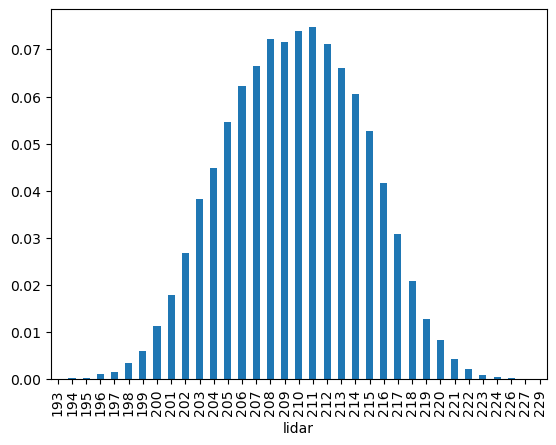

In [11]:
freqs["probs"].sort_index().plot.bar()
# .sort_index()でfreqs["probs"]をセンサの値順に並び替え、
#並び替えたものを.plotでグラフ機能の準備、.barで棒グラフを作成
#メソッドが返すオブジェクトが次のメソッドを持つときメソッドチェーンを行える。
plt.show()
#確率質量関数のグラフ　　確率分布とも呼ばれる

In [12]:
def drowing():    #確率分布に基づいてセンサ値をドローする関数を定義
    return freqs.sample(n=1, weights="probs").index[0]
# .sampleは確率分布に基づいて値を取り出すメソッド　nは取り出す個数、　
# weightsはpropsの列に選ぶ時の確率があることを意味する。
# .index[0]はデータフレームのレコード名（今回はセンサ値）を取り出す 
drowing()

208

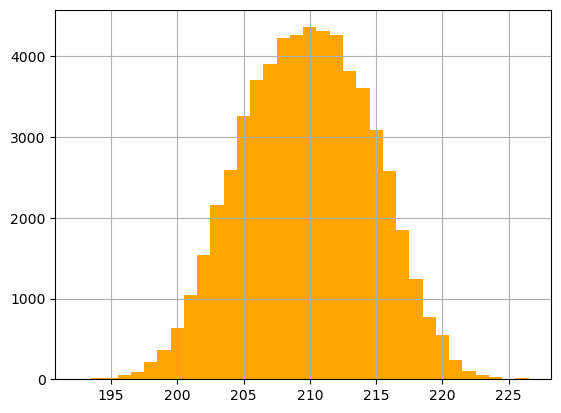

In [13]:
samples = [drowing() for i in range(len(data))]
#samples = [drowing() for i in range(100)]
#samplesという確率分布に基づいて値を取り出したリストを作る。　range(100)は100回繰り返す
simulated = pd.DataFrame(samples,columns=["lidar"])
#samplesをデータフレームにしたsimulatedを作る。　columnsで列名をlidarに変更
p=simulated["lidar"]
#simulated["lidar"]を何度も書くのが大変なのでpと置いた？
p.hist(bins=max(p)-min(p),color="orange",align='left')
plt.show()


In [14]:
def p(z,mu=209.7,dev=23.4):
    return math.exp(-(z-mu)**2/(2*dev))/math.sqrt(2*math.pi*dev)
# muは平均値、devは分散、math.expは指数関数eを表す、math.sqrtは平方根、math.piは3.14(円周率)
# pをガウス分布に従って確率を計算する関数として定義。

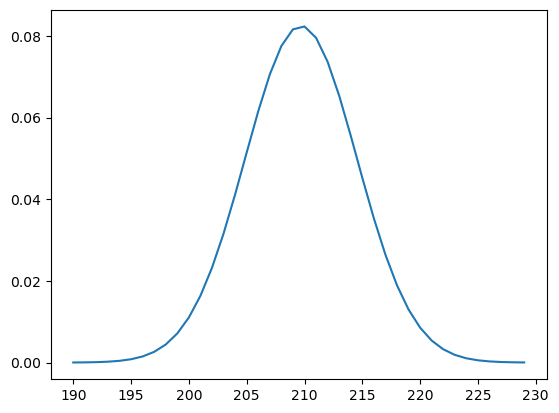

In [15]:
zs = range(190,230)        #zsは190～230の値をとる　横軸のリストになる
ys = [p(z) for z in zs]    #先ほど定義したpにzsを1つずつ代入し、縦軸のリストysを作成

plt.plot(zs,ys)
plt.show()

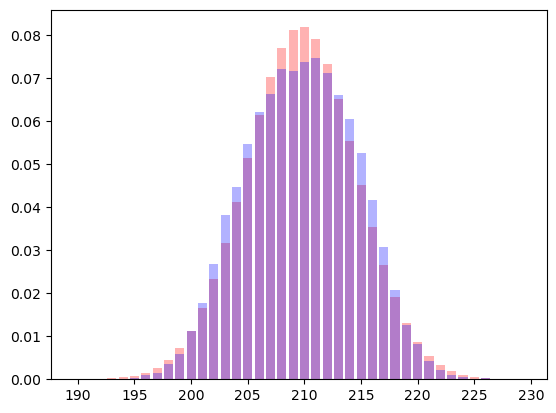

In [17]:
def prob(z,width=0.5):
    return width*(p(z-width)+p(z+width))
#関数pに入力して上底+下底*高さ（幅）/２　　積分が難しいので台形公式で近似　
#横幅を高さと考えたとき(z+0.5)-(z-0.5)=1  width=0.5=1/2
zs = range(190,230)
ys = [prob(z) for z in zs]
# 関数pを積分してセンサ値が整数に限られる場合の確率分布を作る。
# センサ値zに対して[z-0.5,z+0.5)の範囲で積分　（今回は台形公式で近似）

plt.bar(zs,ys,color="red",alpha=0.3)
#alphaは透明度を表す０に近いほど透明　0～1
f = freqs["probs"].sort_index()
plt.bar(f.index,f.values,color="blue",alpha=0.3)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

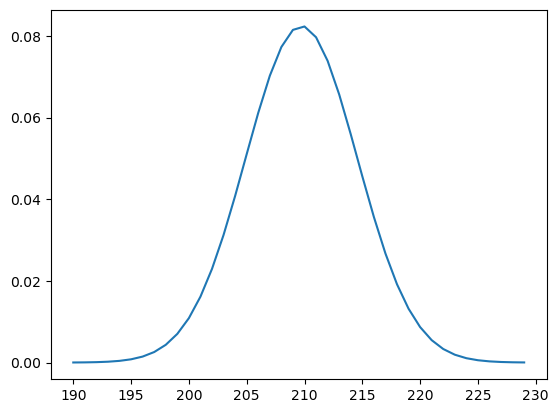

In [22]:
from scipy.stats import norm
# scipyは科学計算モジュール　statsはscipy下のサブモジュール
zs = range(190,230)
ys = [norm.pdf(z,mean1,stddev1) for z in zs]
#norm.pdfはガウス分布の確率密度関数を計算する関数。センサ値、平均値、標準偏差を引数とする。
plt.plot(zs,ys)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

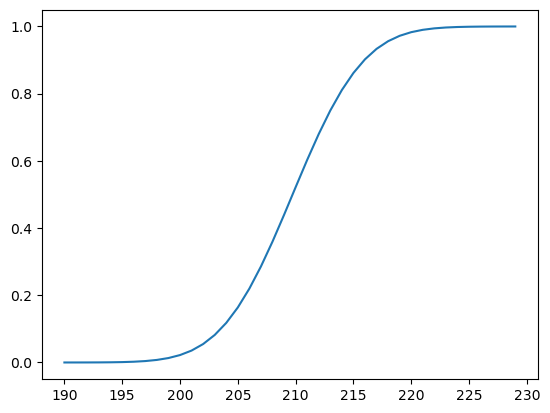

In [21]:
zs = range(190,230)
ys = [norm.cdf(z,mean1,stddev1) for z in zs]
#norm.cdfはガウス分布の累積分布関数を計算する関数。センサ値、平均値、標準偏差を引数とする。
plt.plot(zs,ys)
plt.show

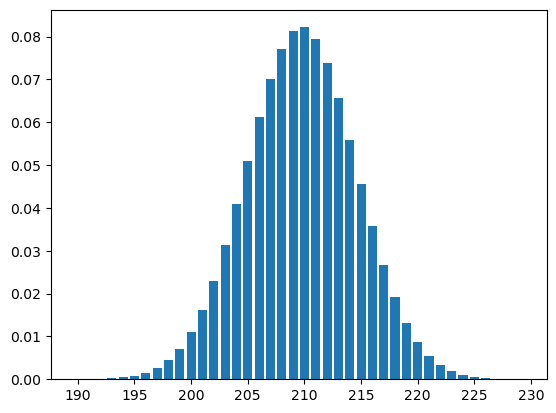

In [24]:
zs = range(190,230)
ys = [norm.cdf(z+0.5,mean1,stddev1)-norm.cdf(z-0.5,mean1,stddev1) for z in zs]
#台形公式で近似した確率分布をnorm.cdfで描く

plt.bar(zs,ys)
plt.show()

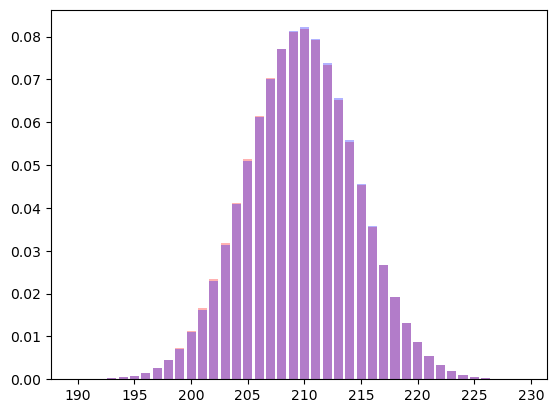

In [27]:
#二つのやり方比較
#def prob(z,width=0.5):
#    return width*(p(z-width)+p(z+width))

zs = range(190,230)
ys1 = [prob(z) for z in zs]
plt.bar(zs,ys1,color="red",alpha=0.3)

ys2 = [norm.cdf(z+0.5,mean1,stddev1)-norm.cdf(z-0.5,mean1,stddev1) for z in zs]
plt.bar(zs,ys2,color="blue",alpha=0.3)

plt.show()

In [31]:
#さいころの期待値を求める
import random

samples = [random.choice([1,2,3,4,5,6])for i in range (10000)]
#[]内からランダムに抽出　10000回ドローしてサンプリング
sum(samples)/len(samples)

3.4862